# Supplementary Figure S49: `s49_predicting_summary`

This notebook rebuilds the figure step by step from its script, `figures/supplementary/sup_predicting_summary.py`. Every code cell below is a verbatim slice of that file, in the order the file defines it: first the imports and configuration, then each helper function with a short explanation, then the body of `main()` laid out as the assembly of the panels, and finally the rendered figure with its caption. Run the cells top to bottom; in the reference environment the PNG written at the end is identical to the submitted manuscript file (see docs/REPRODUCIBILITY.md).

A summary of the predictor comparison: a leaderboard of single predictors of site-residualized control, contrasting the trained models (n = 225 site-models) with the conventionally trained subset (n = 175), plus the best predictor subset evaluated by repeated 10-fold cross-validation. Panel a shows each predictor's site-level correlation with control slope and with control r as a dumbbell, the full family filled and the conventionally trained subset open, with a star when the subset stays significant. Panel b scatters the best model's cross-validated predictions against measured control slope, one colour per monkey. Nothing is computed here: every statistic is read from `sup_predicting_results_no_untrained.pkl` (or `sup_predicting_results.pkl` with `--all-models`), produced by `scripts/preprocessing/build_predicting_results.py`.

## What the script says about itself

Supp fig (predicting_summary) - single-predictor leaderboard + cross-validated best model of neural control, one row.

- **(a)** single-predictor site-|r| leaderboard for every candidate predictor (dumbbell: full-family filled, conventionally-trained open; star = the conventionally-trained subset survives p<.05 with the same sign), control slope then control r, with a boxed key grouping each predictor by what it measures.
- **(b)** the overall best-subset model (the exact subset the analysis selects for control slope) evaluated by repeated 10-fold cross-validation - predicted vs measured site-residualized control slope, one colour per monkey, per-monkey best-fit lines.

Outcome throughout = site-residualized control (the 9-trained residual, matching the rest of the figures; no site-specific intercepts). The canonical render EXCLUDES Untrained (9 trained models); --all-models renders the all-10 variant (filename tag _all10). Reads preproc_data/sup_predicting_results{,_no_untrained}.pkl (outputs of scripts/preprocessing/build_predicting_results.py).

## 1. Environment

A few lines that are not in the script: they make the notebook render exactly like the command-line harness does (single-threaded BLAS, the Agg backend with matplotlib defaults, the repository on the import path) and check that the preprocessed data are present.

In [1]:
import os, sys
from pathlib import Path

# Keep BLAS single-threaded: multithreaded OpenMP together with torch can kill the kernel on macOS.
for _v in ('OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS', 'VECLIB_MAXIMUM_THREADS'):
    os.environ.setdefault(_v, '1')
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

# Render with the Agg backend and matplotlib's defaults, exactly like the figure scripts;
# Jupyter's inline backend would otherwise change dpi and bounding boxes.
os.environ['MPLBACKEND'] = 'Agg'
import matplotlib; matplotlib.use('Agg'); matplotlib.rcdefaults()

# Work from the repository root whether the notebook is opened there or in notebooks/figures/.
REPO = Path.cwd() if (Path.cwd() / 'pnc').exists() else Path.cwd().parents[1]
sys.path.insert(0, str(REPO))
from pnc import paths

# The figures read the preprocessed caches only; this raises a clear message if they are missing.
paths.require(paths.preprocessed_data() / 'brain_red.pkl')   # python data/download_data.py --tier preprocessed
OUT_DIR = paths.output_dir() / 'figures'
OUT_DIR.mkdir(parents=True, exist_ok=True)

## 2. Imports, style and configuration

The script starts by importing the study configuration and figure style from `pnc` (colours, model names, the publication rcParams) and the cache loader, then fixes the constants that the panels share: which sites and models are shown, layout sizes, colour choices, and where the inputs live. `apply_figure_style()` is what makes every figure in the paper look the same.

`PRED2CAT` groups each predictor by what it measures and `CAT_COLORS` colours the groups; `ASHORT` and `PRED_DESC` supply the short labels and one-line descriptions for the key. `MK_LEG` maps monkeys to their area labels. The canonical render excludes Untrained (`EXCL`). One thing to know when reading the code: the results pickle indexes the full analysed family under the key `10` even when that family is the nine trained models.

In [2]:
import os

import pickle

import argparse

import numpy as np

from scipy import stats

import matplotlib

matplotlib.use('Agg')

import matplotlib.pyplot as plt

from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

from matplotlib.lines import Line2D

from pnc import paths

from pnc.utils import (apply_figure_style, FONT_FAMILY, MM, WIDTH_2COL_MM, FIG_FACECOLOR, save_fig,
                       MONKEY_COLORS)

from pnc.manifest import output_name

apply_figure_style()

PREPROC_DATA = str(paths.preprocessed_data())

STEM = output_name('predicting_summary')

# ---- fixed encodings ---------------------------------------------------------
C_SLOPE, C_R = '#E1812C', '#3274A1'                     # outcome hues

MK_LEG = [('red', 'R (aIT)'), ('paul', 'P (cIT)'), ('venus', 'V (V3/V4)'),
          ('leap', 'L (STS)'), ('three0', 'T (STS)')]

ASHORT = {'spectral CoV': 'spectral CoV', 'spectral PR': 'spectral PR',
          'accentuation low-freq': 'low-freq',
          'adversarial sensitivity': 'adv. sens.', 'encoding r (control)': 'enc-r ctrl',
          'encoding r (calibration)': 'enc-r cal', 'accentuation-set eff. dim': 'accent. ED',
          'synth. regularization': 'synth. reg.', 'readout weight norm': 'weight norm',
          'diff-map flatness': 'diff-map flat.', 'Wiener flatness': 'Wiener flat.',
          'ImageNet top-1': 'INet top-1', 'ImageNet top-5': 'INet top-5',
          'ImageNet top-5 margin': 'INet margin'}

# predictor -> category (what kind of thing it measures); leaderboard is coloured by category
# soft/pastel qualitative palette; gradient spectra kept a BOLD blue so the top family stands out
CAT_COLORS = {'gradient spectra': '#1C6DB0', 'adversarial attacks': '#E0928A',
              'encoding scores': '#57ABA5', 'accentuated stimuli': '#AC94D4',
              'latent representations': '#8CBF7B', 'readout weights': '#E0A0C8'}

CAT_ORDER = ['gradient spectra', 'adversarial attacks', 'encoding scores',
             'accentuated stimuli', 'latent representations', 'readout weights']

PRED2CAT = {'spectral CoV': 'gradient spectra', 'spectral PR': 'gradient spectra',
            'Wiener flatness': 'gradient spectra',
            'adversarial sensitivity': 'adversarial attacks',
            'encoding r (calibration)': 'encoding scores', 'encoding r (control)': 'encoding scores',
            'accentuation low-freq': 'accentuated stimuli', 'diff-map flatness': 'accentuated stimuli',
            'synth. regularization': 'accentuated stimuli',
            'accentuation-set eff. dim': 'latent representations', 'readout weight norm': 'readout weights',
            'ImageNet top-1': 'latent representations', 'ImageNet top-5': 'latent representations',
            'ImageNet top-5 margin': 'latent representations'}

PRED_DESC = {'spectral CoV': 'CoV of the encoding-gradient power spectrum',
             'spectral PR': 'participation ratio of the same spectrum',
             'Wiener flatness': 'geo/arith-mean flatness of that spectrum',
             'adversarial sensitivity': 'encoding-axis swing under a PGD attack',
             'encoding r (calibration)': 'encoding $r$, calibration (phase-1) imgs',
             'encoding r (control)': 'encoding $r$, control-session anchors',
             'accentuation low-freq': 'low-freq share of the drive pixel change',
             'diff-map flatness': r'flatness of the drive$-$seed pixel diff',
             'synth. regularization': 'synthesis augmentation-noise level',
             'accentuation-set eff. dim': 'eff. dim of activations to accentuated stim',
             'readout weight norm': 'L2 norm of the ridge readout weights',
             'ImageNet top-1': 'linear-probe top-1 at the readout layer',
             'ImageNet top-5': 'linear-probe top-5 at the readout layer',
             'ImageNet top-5 margin': r'probe top-5$-$top-1 at the readout layer'}

## 3. The building blocks

Each function below is one component of the figure: loading and shaping a cache, computing a statistic, or drawing one panel into an axes it is handed. They are defined here exactly as in the script and used by the assembly in the last section; read them in order, the assembly calls them in roughly the same order.

### `CC(n)`

In [3]:
def CC(n):
    return CAT_COLORS[PRED2CAT[n]]

More configuration used by the functions below.

In [4]:
FS_TTL, FS_LAB, FS_TK, FS_AN, FS_LG, FS_LET = 7.2, 6.3, 5.6, 5.6, 5.8, 11

# results pickle + derived module state the panel helpers read; filled by _load() at call time
# (was import-time work keyed on env EXCLUDE_UNTRAINED)
EXCL = True                                              # canonical = without Untrained

R = FAM_LAB = GN = LEAD = A_MARKERS = None

### `_load(exclude_untrained=True)`

Loads the pickle, sets the family label, builds the leaderboard list (the pickle's predictor groups plus a few extras if they are missing), and prepares the marker-legend handles with the two sample sizes.

In [5]:
def _load(exclude_untrained=True):
    global EXCL, R, FAM_LAB, GN, LEAD, A_MARKERS
    EXCL = exclude_untrained
    R = pickle.load(open(paths.require(os.path.join(
        PREPROC_DATA, 'sup_predicting_results_no_untrained.pkl' if EXCL
        else 'sup_predicting_results.pkl'),
        hint='python scripts/preprocessing/build_predicting_results.py'
             + (' --exclude-untrained' if EXCL else '')), 'rb'))
    FAM_LAB = 'Trained models' if EXCL else 'All models'
    GN = R['meta']['GNAMES']
    LEAD = list(GN) + [n for n in ('Wiener flatness', 'ImageNet top-1', 'ImageNet top-5',
                                   'ImageNet top-5 margin') if n not in GN]
    A_MARKERS = [Line2D([0], [0], marker='o', ls='', mfc='#333', mec='#333', ms=3.8, label=f'{FAM_LAB} (n = {R["n"][10]})'),
                 Line2D([0], [0], marker='o', ls='', mfc='white', mec='#333', mew=1.0, ms=3.8,
                        label=f'Conventionally trained (n = {R["n"][7]})'),
                 Line2D([0], [0], marker='*', ls='', mfc='#333', mec='#333', ms=7,
                        label='Remains significant ($p$<0.05 @ n=175)')]

### `despine(ax, which=('top', 'right'))`

In [6]:
def despine(ax, which=('top', 'right')):
    for s in which:
        ax.spines[s].set_visible(False)
    for s in ax.spines.values():
        s.set_linewidth(0.6)
    ax.tick_params(labelsize=FS_TK, width=0.6, length=2.6)

### `boxleg(leg)`

In [7]:
def boxleg(leg):
    leg.set_frame_on(True)
    leg.get_frame().set(facecolor='white', edgecolor='#cccccc', linewidth=0.6, alpha=0.9)
    return leg

### `title(fig, x, y, s, ha='center', size=FS_TTL)`

In [8]:
def title(fig, x, y, s, ha='center', size=FS_TTL):
    fig.text(x, y, s, fontsize=size, fontfamily=FONT_FAMILY, va='bottom', ha=ha)

### `letter(fig, x, y, s)`

In [9]:
def letter(fig, x, y, s):
    fig.text(x, y, s, fontsize=FS_LET, fontweight='bold', fontfamily=FONT_FAMILY, va='top', ha='left')

### `kfold_best_model()`

The subset the analysis selects as the best model for the SITE-RESIDUALIZED control slope, with its repeated 10-fold cross-validated out-of-fold predictions + CV R^2 (cached in the results pickle). Returns pred/true, CV R^2, predicted-vs-measured Pearson r, the explainable ceiling and the chosen predictors.

Pulls the cached best-subset result for control slope: out-of-fold predictions, measured values, monkey labels, cross-validated R squared, the predicted-versus-measured r, the explainable ceiling and the chosen predictors.

In [10]:
# ---- best-subset model, repeated 10-fold CV -----------------------------------
def kfold_best_model():
    """The subset the analysis selects as the best model for the SITE-RESIDUALIZED control slope,
    with its repeated 10-fold cross-validated out-of-fold predictions + CV R^2 (cached in the
    results pickle). Returns pred/true, CV R^2, predicted-vs-measured Pearson r, the explainable
    ceiling and the chosen predictors."""
    b = R['best'][(10, 'slope')]
    pred, true = np.asarray(b['pred'], float), np.asarray(b['true'], float)
    return dict(pred=pred, true=true, monkey=np.asarray(b['monkey']),
                r2=float(b['cvr2']), r=float(stats.pearsonr(pred, true)[0]),
                ceiling=float(R['ceiling'][(10, 'slope')]), chosen=list(b['chosen']))

### `panel_leaderboard(fig, cell)`

---- panel: single-predictor leaderboard ---------------------------------------

Two side-by-side columns (slope, then r) sharing one predictor order, sorted by the full family's correlation magnitude with slope. Each value is multiplied by the sign of the full family's correlation so the full set reads positive and a reversal in the conventionally trained subset dips left of zero. Stars mark predictors with p < 0.05 in that subset; the two gradient-spectral labels are bolded.

In [11]:
# ---- panel: single-predictor leaderboard ---------------------------------------
def panel_leaderboard(fig, cell):
    order = sorted(LEAD, key=lambda n: -R['rawcorr'][(10, 'slope')][n]['mag'])
    y = np.arange(len(order))[::-1]
    sub = GridSpecFromSubplotSpec(1, 2, subplot_spec=cell, wspace=0.10)
    axS = fig.add_subplot(sub[0, 0]); axR = fig.add_subplot(sub[0, 1])
    def flip(n, tag):     # orient to the all-models sign so the full set reads positive
        return 1.0 if R['rawcorr'][(10, tag)][n]['signed'] >= 0 else -1.0
    vals = [R['rawcorr'][(f, t)][n]['signed'] * flip(n, t)
            for f in (10, 7) for t in ('slope', 'r') for n in order]
    xlo, xhi = min(vals) - 0.05, max(vals) * 1.12
    for ax, tag, ccol in [(axS, 'slope', C_SLOPE), (axR, 'r', C_R)]:
        for yi, n in zip(y, order):
            fl = flip(n, tag)
            av = R['rawcorr'][(7, tag)][n]['signed'] * fl     # conventionally trained (open); dips <0 if it reverses
            bv = R['rawcorr'][(10, tag)][n]['signed'] * fl    # all models (filled)
            ax.plot([av, bv], [yi, yi], color='#C4C4C4', lw=1.1, zorder=1, solid_capstyle='round')
            ax.scatter(av, yi, s=15, facecolor='white', edgecolor=CC(n), lw=1.0, zorder=3)
            ax.scatter(bv, yi, s=18, color=CC(n), zorder=4)
            if R['rawcorr'][(7, tag)][n]['p'] < 0.05:         # conventionally-trained significant
                ax.scatter(av, yi + 0.36, s=30, marker='*', color=CC(n), lw=0, zorder=5)
        despine(ax)
        ax.set_ylim(-0.6, len(order) - 0.4); ax.set_xlim(xlo, xhi)
        ax.set_xticks([0, 0.3, 0.6]); ax.axvline(0, color='#999', lw=0.6, zorder=0)
        ax.set_xlabel('Correlation with control ' + ('slope' if tag == 'slope' else 'r') +
                      '\n(Site residuals; sign-flipped)', fontsize=FS_LAB, fontfamily=FONT_FAMILY)
    axS.set_yticks(y); axS.set_yticklabels([ASHORT[n] for n in order])
    for t, n in zip(axS.get_yticklabels(), order):
        t.set_color(CC(n)); t.set_fontsize(FS_LAB - 0.6)
        t.set_fontweight('bold' if n in ('spectral CoV', 'spectral PR') else 'normal')
    axS.tick_params(axis='y', length=0)
    axR.set_yticks(y); axR.set_yticklabels([])
    return axS, axR

### `panel_best(fig, cell)`

---- panel: overall best model, repeated 10-fold CV -----------------------------

Scatter of predicted versus measured control slope, coloured by monkey, with a per-monkey regression line spanning that monkey's measured range and a dashed identity line on a square axis.

In [12]:
# ---- panel: overall best model, repeated 10-fold CV -----------------------------
def panel_best(fig, cell):
    ax = fig.add_subplot(cell)
    b = kfold_best_model(); pred, true, mks = b['pred'], b['true'], b['monkey']
    for mk, _ in MK_LEG:
        sel = mks == mk; c = MONKEY_COLORS[mk]
        if sel.sum() == 0:
            continue
        ax.scatter(pred[sel], true[sel], s=12, color=c, alpha=0.85, lw=0, zorder=3)   # uniform dots
        if sel.sum() > 2:
            sl, ic, *_ = stats.linregress(pred[sel], true[sel])                       # measured ~ sl*pred + ic
            ys = np.array([true[sel].min(), true[sel].max()])                         # span the monkey's Y range
            xs = (ys - ic) / sl if abs(sl) > 1e-6 else np.array([pred[sel].min(), pred[sel].max()])
            ax.plot(xs, ys, color=c, lw=1.6, alpha=1.0, solid_capstyle='round', zorder=4)
    lo = min(pred.min(), true.min()); hi = max(pred.max(), true.max()); pad = 0.06 * (hi - lo)
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], '--', color='#888', lw=0.8, zorder=1)
    ax.set_xlim(lo - pad, hi + pad); ax.set_ylim(lo - pad, hi + pad); ax.set_box_aspect(1)
    despine(ax)
    ax.set_xlabel('Predicted control slope (10-fold CV)', fontsize=FS_LAB, fontfamily=FONT_FAMILY)
    ax.set_ylabel('Measured control slope (site-resid.)', fontsize=FS_LAB, fontfamily=FONT_FAMILY)
    return ax, b

### `draw_desc_box(fig, cell)`

Boxed key: every candidate predictor grouped and coloured by what it measures.

The boxed key: predictors listed under their category, each with its short label and description.

In [13]:
# ---- predictor-description key ---------------------------------------------------
def draw_desc_box(fig, cell):
    """Boxed key: every candidate predictor grouped and coloured by what it measures."""
    ax = fig.add_subplot(cell)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    for s in ax.spines.values():
        s.set(edgecolor='#bbbbbb', linewidth=0.6)
    bycat = {}
    for p in LEAD:
        bycat.setdefault(PRED2CAT[p], []).append(p)
    y, dh = 0.975, 0.0415
    ax.text(0.04, y, 'Legend', fontsize=FS_LG - 0.4, fontweight='bold',
            fontfamily=FONT_FAMILY, va='top', ha='left'); y -= 0.072
    for cat in CAT_ORDER:
        ax.text(0.03, y, cat, fontsize=FS_LG - 1.3, fontweight='bold', color=CAT_COLORS[cat],
                fontfamily=FONT_FAMILY, va='top', ha='left'); y -= dh
        for p in bycat.get(cat, []):
            ax.text(0.07, y, ASHORT[p], fontsize=FS_LG - 1.9, color=CAT_COLORS[cat], fontweight='bold',
                    fontfamily=FONT_FAMILY, va='top', ha='left')
            ax.text(0.33, y, PRED_DESC[p], fontsize=FS_LG - 2.4, color='#444',
                    fontfamily=FONT_FAMILY, va='top', ha='left')
            y -= dh
        y -= 0.006
    return ax

## 4. Assembling the figure

This is the body of `main()` from the script, laid out step by step: it builds the figure canvas, calls the building blocks to fill each panel, and saves the result with `save_fig`, which trims the white border so the file matches the submitted figure.

A single row of three cells: the leaderboard (split internally into slope and r), the predictor key, and the best-model scatter. Titles, the stats line, the two legends and the letters are positioned after a draw from the axes' actual positions.

In [14]:
# Inputs of the assembly below (these are the parameters of main() in the script).
out_dir = str(OUT_DIR)
exclude_untrained = True
# Change any of them to render one of the variants described in the script header.

**Step 1**

Loads the results, creates the figure and grid, and draws the three panels.

In [15]:
_load(exclude_untrained)
fig = plt.figure(figsize=(WIDTH_2COL_MM * MM, 72 * MM), facecolor=FIG_FACECOLOR)
gs = GridSpec(1, 3, figure=fig, left=0.075, right=0.985, top=0.875, bottom=0.225,
              width_ratios=[1.9, 0.95, 0.95], wspace=0.26)
laS, laR = panel_leaderboard(fig, gs[0])              # leaderboard (slope | r)
draw_desc_box(fig, gs[1])                             # predictor key
axl, best = panel_best(fig, gs[2])

**Step 2**

Renders once, then adds the two panel titles, the R squared / r / ceiling-fraction line above panel b, the marker legend strip under the leaderboard, the monkey legend and the best-subset footnote under panel b, and the letters.

In [16]:
fig.canvas.draw()
pl = laS.get_position(); plr = laR.get_position(); pc = axl.get_position()
title(fig, (pl.x0 + plr.x1) / 2, pl.y1 + 0.042,
      'Comparison of different predictors of neural control outcomes')
title(fig, (pc.x0 + pc.x1) / 2, pc.y1 + 0.042, 'Best model, 10-fold CV')
# stats line in the band between panel-b title and the axes (no in-axes box)
fig.text((pc.x0 + pc.x1) / 2, pc.y1 + 0.008,
         f'$R^2$ = {best["r2"]:.2f}    $r$ = {best["r"]:.2f}    '
         f'({100 * best["r2"] / best["ceiling"]:.0f}% of the {best["ceiling"]:.2f} $R^2$ ceiling)',
         ha='center', va='bottom', fontsize=FS_AN - 0.6, color='0.35', fontfamily=FONT_FAMILY)
# marker key as a horizontal strip in the bottom margin, under the leaderboard columns
lgm = fig.legend(handles=A_MARKERS, ncol=3, loc='lower center',
                 bbox_to_anchor=((pl.x0 + plr.x1) / 2, 0.005), fontsize=FS_LG - 2.1,
                 handletextpad=0.3, columnspacing=1.0, borderpad=0.3, markerscale=0.85)
boxleg(lgm)
# panel-b monkey key + best-subset footnote in the whitespace UNDER its x-label
mk_h = [Line2D([0], [0], marker='o', ls='', mfc=MONKEY_COLORS[mk], mec='none', ms=3.0, label=lg)
        for mk, lg in MK_LEG]
boxleg(fig.legend(handles=mk_h, ncol=3, loc='lower center',
                  bbox_to_anchor=((pc.x0 + pc.x1) / 2, 0.055), fontsize=FS_LG - 2.1,
                  handletextpad=0.2, columnspacing=0.8, labelspacing=0.25, borderpad=0.3,
                  markerscale=0.9))
fig.text((pc.x0 + pc.x1) / 2, 0.012, 'best subset: ' + ' + '.join(ASHORT[n] for n in best['chosen']),
         ha='center', va='bottom', fontsize=FS_AN - 1.0, color='#555', fontfamily=FONT_FAMILY)
letter(fig, pl.x0 - 0.055, pl.y1 + 0.090, 'a')
letter(fig, pc.x0 - 0.030, pc.y1 + 0.090, 'b')

**Step 3**

Saves the figure and prints the chosen subset, its cross-validated R squared and the ceiling.

In [17]:
path = save_fig(fig, os.path.join(out_dir, STEM + ('' if EXCL else '_all10')))
plt.close(fig)
print('best subset (control slope):', R['best'][(10, 'slope')]['chosen'])
print('best-model 10-fold CV R2 =', round(kfold_best_model()['r2'], 3),
      ' ceiling', round(R['ceiling'][(10, 'slope')], 3))
print('saved', path)
png = path

best subset (control slope): ['spectral CoV', 'spectral PR', 'adversarial sensitivity', 'ImageNet top-1']
best-model 10-fold CV R2 = 0.514  ceiling 0.855
saved /private/tmp/claude-501/-Users-jacobprince-KonkLab-Dropbox-Jacob-Prince-Research-Prince-Accentuate-VVS-Manuscript/bca6882d-ec2d-4dbd-beb1-0d67d8b1fcc7/scratchpad/nb_exec_out/figures/s49_predicting_summary.png


## 5. The figure

`png` now points at the rendered file. A downscaled preview follows (the full-resolution PNG is the file itself, `s49_predicting_summary.png` in the output directory).

The gradient-spectral predictors should lead the leaderboard and keep their stars, while the adversarial-sensitivity dumbbell has its open marker crossing zero. The caption gives R squared = 0.51 and r = 0.72 for the best model, 60% of the 0.85 ceiling; treat that as an optimistic bound, since the same folds were used to select and to score the subset. `--all-models` renders the ten-model variant.

/private/tmp/claude-501/-Users-jacobprince-KonkLab-Dropbox-Jacob-Prince-Research-Prince-Accentuate-VVS-Manuscript/bca6882d-ec2d-4dbd-beb1-0d67d8b1fcc7/scratchpad/nb_exec_out/figures/s49_predicting_summary.png


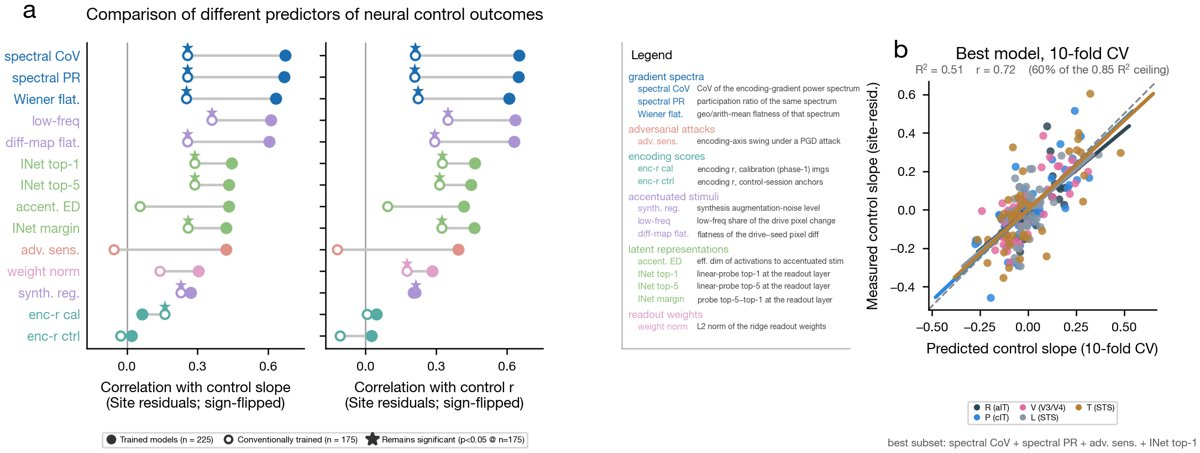

In [18]:
import io
from IPython.display import Image, display
from PIL import Image as PILImage

# A JPEG preview keeps the notebook small; open the PNG for full detail.
print(png)
im = PILImage.open(png).convert("RGB")
im.thumbnail((1200, 1200))
buf = io.BytesIO(); im.save(buf, "JPEG", quality=85, optimize=True)
display(Image(data=buf.getvalue(), format="jpeg", width=900))

**Supplementary Figure S49. Predicting neural control: single-predictor leaderboard and cross-validated best model.** Site-residualized, cross-validated comparison of candidate predictors of parametric control, contrasting the trained models ($n = 225$ site-models) with the conventionally-trained subset ($n = 175$). (A) Single-predictor site-level correlation with control slope (left) and control $r$ (right; sign-flipped site residuals); each candidate predictor is a dumbbell with the trained-models value filled and the conventionally-trained value open, and a star marking predictors that remain significant ($p < 0.05$) at $n = 175$. Predictors are grouped by what they measure (legend): gradient spectra (spectral CoV, spectral PR, Wiener flatness), adversarial attacks (encoding-axis swing under a PGD attack), encoding scores (calibration- and control-phase encoding $r$, both over held-out images), accentuated stimuli (synthesis regularization, low-frequency share of the drive pixel change, flatness of the drive--seed pixel difference), latent representations (effective dimensionality of activations to accentuated stimuli; ImageNet linear-probe top-1, top-5, and margin at the readout layer), and readout weights (L2 norm of the ridge readout weights). The gradient-spectral summaries lead and retain significance among the conventionally trained models, whereas adversarial sensitivity collapses there (open marker crosses zero). (B) The best predictor subset (spectral CoV + spectral PR + adversarial sensitivity + ImageNet top-1), identified by exhaustively scoring every subset of the eleven site-varying predictor groups by repeated 10-fold cross-validated $R^2$ under a per-animal design (per-animal intercepts and slopes), shown as predicted versus measured site-residualized control slope, one color per monkey with per-monkey fits and the identity line; $R^2 = 0.51$, $r = 0.72$, reaching $60%$ of the $0.85$ split-half $R^2$ ceiling. We note that the same cross-validation folds were used to score and select predictors; best-model $R^2$ as reported here therefore reflects an optimistic upper bound on the outcome measure.